<hr style="border:1px solid #808080">                                                                                                                   </hr>
<h1 style="color:#0176DE;text-align:center;margin:0;padding-top:0;"> <b>Ayudantía 2 - Python y Numpy para Computación científica</b>                                                                           </h1>
<h1 style="color:#0176DE;text-align:center;margin:0;padding-top:0;"> <b>IBM2020 Introducción a la Biomecánica</b>                                                                           </h1>
<p style=padding:0;margin:0>
<h3 style="color:#c1ccdb;text-align:center;margin:0;padding:0;"> Profesor - <span style="color:#dbdbdb;text-align:center;"><b>Daniel Hurtado</b></span></h3>
<h3 style="color:#c1ccdb;text-align:center;margin:0;padding:0;">Ayudantes - <span style="color:#dbdbdb;text-align:center;"><b>Vicente Zúñiga, Clio Kipreos, Catalina Neira</b></span></h3> 
</p>
<h4 style="color:#dbdbdb;text-align:center;margin:0;padding:0;">Instituto de Ingeniería Biológica y Médica<br>Escuela de Ingeniería<br>  Pontificia Universidad Católica de Chile <br></h4>
<hr style="border:1px solid #808080">                                                                                                                   </hr>

## Introducción
La biomecánica estudia el comportamiento mecánico de los tejidos blandos, usualmente sometidos a grandes deformaciones, y que presentan relaciones no lineales entre tensión y deformación. Para describir cuantitativamente este comportamiento, es necesario saber definir un dominio $\Omega$ que represente el cuerpo a estudiar, cómo aplicar deformaciones, graficar sus tensiones y extraer resultados que se puedan entender fácilmente. 

En esta ayudantía cubriremos las herramientas y librerías de Python necesarias para este curso y para resolver problemas de computación científica en general, y haremos un ejercicio aplicado de cambio de coordenadas.

## Creación de dominios y transformación de coordenadas
Para mostrar la configuración inicial y actual de un determinado dominio, es necesario definirlo y aplicarle una función $\varphi$, que conocemos como el **mapeo de deformación**. Usaremos la función `numpy.meshgrid` para crear coordenadas con las que podremos trabajar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 50

# Genera los valores de R y Theta de forma independiente
R = np.linspace(5, 10, N)
Theta = np.linspace(0, (7/4)*np.pi, 2*N)

# Genera nuestro espacio de coordenadas polares
RR, TT = np.meshgrid(R, Theta) 

print(R.shape)
print(Theta.shape)

print(RR.shape)
print(TT.shape)

(50,)
(100,)
(100, 50)
(100, 50)


Mostramos nuestro dominio en ambos sistemas de coordenadas.

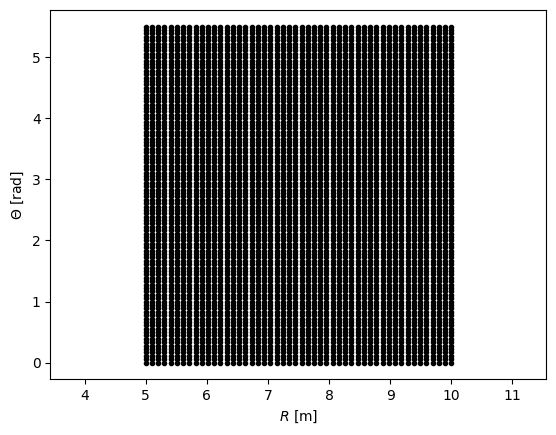

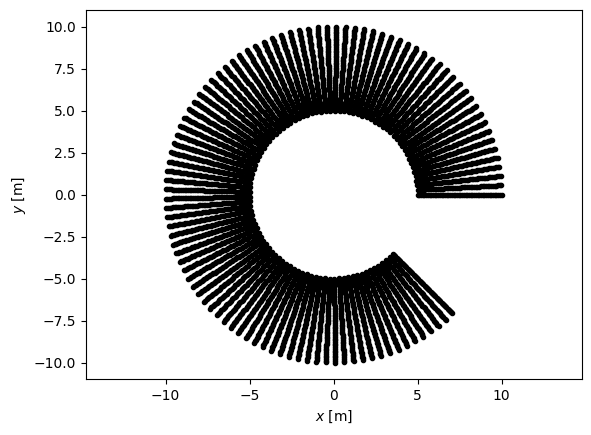

In [3]:
plt.figure()
plt.plot(RR, TT, '.', color='black')
plt.axis('equal')
plt.xlabel(r"$R$ [m]")
plt.ylabel(r"$\Theta$ [rad]")
plt.show()


XX = RR*np.cos(TT)
YY = RR*np.sin(TT)


plt.figure()
plt.plot(XX, YY, '.', color='black')
plt.axis('equal')
plt.xlabel(r"$x$ [m]")
plt.ylabel(r"$y$ [m]")
plt.show()

Ahora aplicamos nuestro mapeo de deformación y graficamos. 

Nótese que cada operación se realiza sobre nuestro dominio `(aa, bb)` y no sobre los arrays independientes `(a, b)`.

In [4]:
def phi(R, T):
    r = R**2 / 8
    t = T / 10
    return r, t


rr, tt = phi(RR,TT)

xx = rr*np.cos(tt)
yy = rr*np.sin(tt)

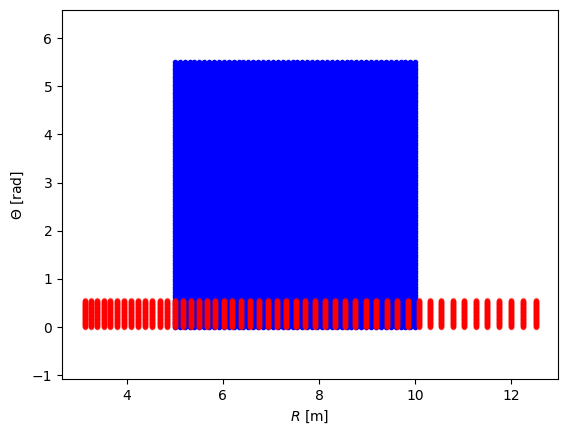

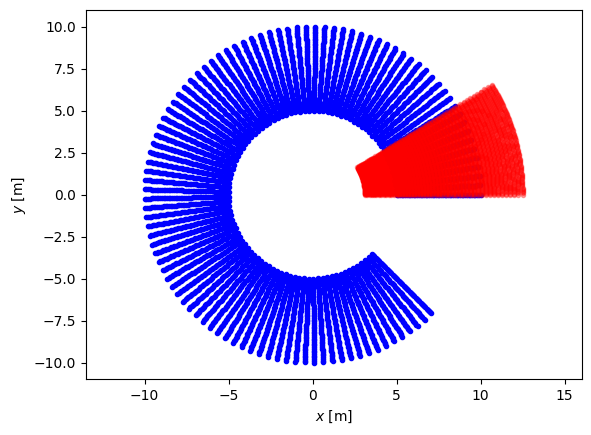

In [5]:
plt.figure()
plt.plot(RR, TT, '.', color='blue', alpha=1)
plt.plot(rr, tt, '.', color='red', alpha=1/3)
plt.axis('equal')
plt.xlabel(r"$R$ [m]")
plt.ylabel(r"$\Theta$ [rad]")
plt.show()


plt.figure()
plt.plot(XX, YY, '.', color='blue', alpha=1)
plt.plot(xx, yy, '.', color='red', alpha=1/3)
plt.axis('equal')
plt.xlabel(r"$x$ [m]")
plt.ylabel(r"$y$ [m]")
plt.show()

## Ejercicio: Cambio de coordenadas en estado de tensiones planas

Ahora supongamos que tenemos sobre un cuerpo un estado de tensiones planas $\sigma$, que se representa en un sistema de coordenadas $\{X, Y, Z\}$ como:

$$\sigma_{XYZ} = \begin{pmatrix}
\sigma_1 & \tau & 0\\
\tau & \sigma_2 & 0\\
0 & 0 & \sigma_3
\end{pmatrix} = 
\begin{pmatrix}
12 & 7 & 0\\
7 & 4 & 0\\
0 & 0 & 5
\end{pmatrix} 
$$

Nos interesa saber cómo cambian los valores de las tensiones cuando rotamos nuestro sistema de coordenadas en un ángulo arbitrario $\theta$. 

Esta transformación se representa con

$$
\sigma' = Q \sigma Q^\top, \qquad 
Q = \begin{pmatrix}
\cos\theta & \sin\theta & 0\\
-\sin\theta & \cos\theta & 0\\
0 & 0 & 1
\end{pmatrix}
$$

Donde $Q$ es la matriz de rotación en el plano XY para un ángulo $\theta$.


--- 

1. Grafique el valor de las componentes $\sigma_1, \tau_{12}, \sigma_2$ para cada valor de $\theta$.

2. Determine de numérica, para qué valor de $\theta$ hay tensión de corte nula y luego máxima.

3. Desarrolle una expresión analítica para las componentes del tensor de tensiones.

---


### 1. Solución numérica

In [6]:
import numpy as np
import matplotlib.pyplot as plt

### 2. Valores de $\theta$ para corte máximo y nulo

### 3. Solución analítica

Datos:
$$
\sigma_{XYZ} = \begin{pmatrix}
\sigma_1 & \tau & 0\\
\tau & \sigma_2 & 0\\
0 & 0 & \sigma_3
\end{pmatrix}, \qquad
Q = \begin{pmatrix}
\cos\theta & \sin\theta & 0\\
-\sin\theta & \cos\theta & 0\\
0 & 0 & 1
\end{pmatrix}, \qquad
\sigma = \sigma^\top
$$


Hint: Recuerde esa famosa manera gráfica de expresar un estado de tensiones planas. 